Code adapted from Daria Kussovska, dnk2118@columbia.edu

# Bursting analysis

Here, we are trying to generate bursts and compare to a Poisson distribution, to see if certain combinations of cells burst signficantly more than generated by chance (Poisson distribution). We do that analysis across subjects. First, we load the data we want to look into, and we define groups of categories of neurons that we want to test. 

In [1]:
import numpy as np
import pandas as pd
import sys
import importlib
import os
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.signal.windows import gaussian
from scipy.stats import shapiro, ttest_rel, wilcoxon

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
from bootstrap_method import *


In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# find folder names within model directory
all_models_dir = '/scratch/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)

# choose model 0 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [3]:
# Define parameters for bursting analysis (in ms)
bin_size = 70
sigma = 40
prominence_threshold_percentile = 95

 We set up groups of neurons to test individually. Then, we iterate over each of those groups of neurons. 

For each group of neurons, we loop through each trial and neuron. 
- collect spike times within the delay window
- adjust the spike times based on the trial index, so that all trials form a continuous timeline
- gathers the total spike count per neuron and the number of trials where the neuron fired. 

- compute each neuron's average firing rate across trials, which is later needed to generate the Poisson surrogates. 

- Spikes from all trials are binned and smoothed with a Gaussian kernel
- Bursts are defined as prominent peaks in the smoothed signal (above a threshold defined by a percentile)
- The number of peaks = number of bursts.

- Simulate spiking based on each neuron's average firing rate in each trial: A Poisson distribution determines the number of spikes and spikes are placed randomly in time. 

- Average number of bursts across the 100 Poisson simulations is saved.

In [4]:
# Load data

# neural data
importlib.reload(ld)
_, spk_df, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=True, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
times_spk, _,_ = ld.get_times_dict('spk', condn_phrase, condn_num)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num)

In [5]:
spk_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,"[0.0, 3710.0, 4404.0, 15955.0, 17421.0, 19622....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
1,1,0,exc,"[0.0, 6821.0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
2,2,0,inh,"[1304.0, 3437.0, 5146.0, 6980.0, 7811.0, 9111....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
3,3,0,exc,"[1, 0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
4,4,0,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150


In [6]:
rates_data.shape

(2055, 200, 1000)

### Need to calculate:

- each neuron's average firing rate during delay, in general (across trials)
    - used to calculate poisson spike train
- 95% percentile of the firing rate
    - used to calculate bursts in the real data
    - used to calculate bursts in the simulated data

note: calculate bursts by detecting peaks above the threshold calculated from the percentile

#### start with model, using rates instead of spikes

In [ ]:
# get delay fr and flatten trials
delay_fr = rates_data[int(times_ms['stim1_off']):int(times_ms['stim2_on']), :,:]
trial_dur = delay_fr.shape[0]
n_neurons = delay_fr.shape[1]
n_trials = delay_fr.shape[2]
delay_fr = delay_fr.transpose(2,0,1).reshape(-1, delay_fr.shape[1])
print(delay_fr.shape)

# get the average firing rate for each neuron for each trial during maintenance
neuron_avg_fr = np.mean(rates_data[int(times_ms['stim1_off']):int(times_ms['stim2_on']), :,:], axis=0)
print(neuron_avg_fr.shape)

# get the 95th percentile
prominence_threshold = np.percentile(delay_fr, prominence_threshold_percentile, axis=0)
print(prominence_threshold.shape)



(750000, 200)
(200, 1000)
(200,)


In [6]:
# make dataframe of burst peaks for each trial and neuron
burst_peaks_rows = []
for i_neuron in range(n_neurons):
    burst_peaks, _ = signal.find_peaks(delay_fr[:,i_neuron], prominence=prominence_threshold[i_neuron])
    for j_trial in range(n_trials):
        burst_peaks_trial = burst_peaks[burst_peaks >= j_trial*trial_dur]
        burst_peaks_trial = burst_peaks_trial[burst_peaks_trial < (j_trial+1)*trial_dur] - j_trial*trial_dur

        burst_peaks_rows.append({
            'neuron': i_neuron,
            'trial': j_trial,
            'peak_times': burst_peaks_trial + times_ms['stim1_off'],
            'n_peaks': len(burst_peaks_trial),
            'prominence': prominence_threshold[i_neuron]
        })
burst_peaks_df = pd.DataFrame(burst_peaks_rows)


In [116]:
burst_peaks_df

,neuron,trial,peak_times,n_peaks,prominence
0,0,0,"[803.0, 876.0, 986.0]",3,11.588488
1,0,1,[409.0],1,11.588488
2,0,2,[],0,11.588488
3,0,3,"[593.0, 750.0, 864.0, 1002.0]",4,11.588488
4,0,4,"[802.0, 868.0]",2,11.588488
...,...,...,...,...,...
199995,199,995,"[551.0, 617.0, 858.0, 1034.0]",4,21.865418
199996,199,996,"[473.0, 555.0, 811.0, 856.0, 891.0, 992.0]",6,21.865418
199997,199,997,"[449.0, 822.0, 868.0, 906.0, 967.0, 1072.0, 11...",7,21.865418
199998,199,998,"[752.0, 852.0]",2,21.865418


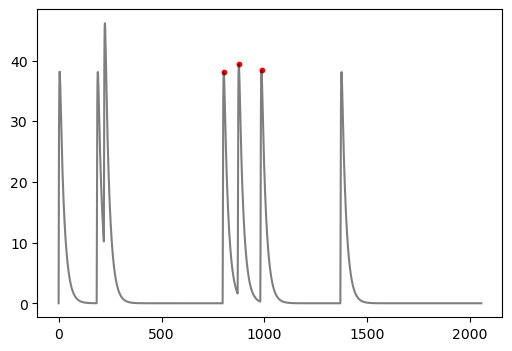

In [7]:
# plot one example neuron trial

i_neuron = 0
j_trial = 0
plt.figure(figsize=(6,4))
plt.plot(rates_data[:,i_neuron,j_trial], color='k', alpha=0.5)
burst_times = burst_peaks_df['peak_times'][burst_peaks_df['neuron'] == i_neuron][burst_peaks_df['trial'] == j_trial].iloc[0]
plt.scatter(burst_times, rates_data[burst_times.astype(int),i_neuron,j_trial], color='r', s=10)

[   0.    185.5   220.2   797.75  871.05  981.1  1370.05]


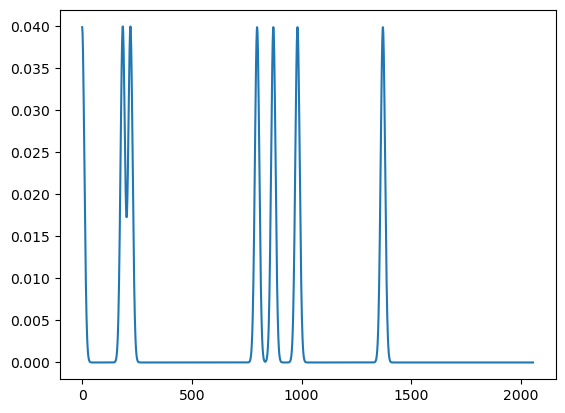

In [9]:
# get cell 0 trial 0 in spk_df
spk_times = spk_df[(spk_df['cell_id'] == i_neuron) & (spk_df['trial_id'] == j_trial)]['spk_times'].values[0] / fs_dict['spk'] * 1000
print(spk_times)
smoothed_rate = convert_spike_to_rate(spk_times, times_ms['T'], 1, 10)

plt.plot(smoothed_rate);

In [122]:
spk_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,"[0.0, 3710.0, 4404.0, 15955.0, 17421.0, 19622....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
1,1,0,exc,"[0.0, 6821.0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
2,2,0,inh,"[1304.0, 3437.0, 5146.0, 6980.0, 7811.0, 9111....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
3,3,0,exc,"[1, 0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
4,4,0,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150


array([   0.  ,  769.85,  845.6 , 1442.1 , 1472.2 , 1549.05, 1704.15,
       1788.1 , 1842.2 , 1888.45, 1946.95])

In [142]:
smoothed_rate = convert_spike_to_rate(spk_times, times_ms['T'], 1, 10)

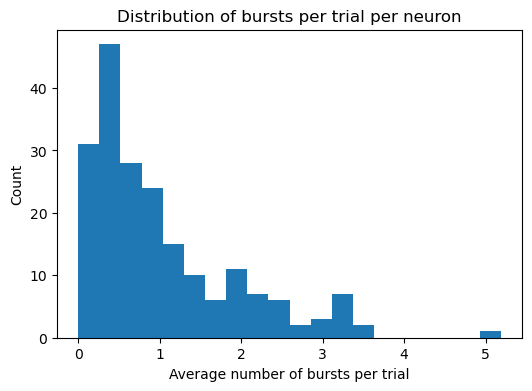

In [121]:
# get average number of bursts per trial per neuron
mean_bursts_per_trial = np.zeros((n_neurons))
for i_neuron in range(n_neurons):
    neuron_burst_peaks = burst_peaks_df[burst_peaks_df['neuron'] == i_neuron]
    mean_bursts_per_trial[i_neuron] = np.mean(neuron_burst_peaks['n_peaks'].values)

# plot as hist
plt.figure(figsize=(6,4))
plt.hist(mean_bursts_per_trial, bins=20)
plt.xlabel('Average number of bursts per trial')
plt.ylabel('Count')
plt.title('Distribution of bursts per trial per neuron')
plt.show()

In [74]:
burst_peaks, _ = signal.find_peaks(delay_fr[:,0], prominence=prominence_threshold[0])

In [76]:
burst_peaks.shape

(1239,)

In [80]:
burst_peaks_trials

{0: array([398, 471, 581]),
 1: array([4]),
 2: array([], dtype=int64),
 3: array([188, 345, 459, 597]),
 4: array([397, 463]),
 5: array([213, 405]),
 6: array([], dtype=int64),
 7: array([284]),
 8: array([], dtype=int64),
 9: array([], dtype=int64),
 10: array([ 61, 245]),
 11: array([123, 244]),
 12: array([0]),
 13: array([], dtype=int64),
 14: array([261]),
 15: array([], dtype=int64),
 16: array([333, 678]),
 17: array([290, 447]),
 18: array([], dtype=int64),
 19: array([214]),
 20: array([204, 573]),
 21: array([ 47, 120]),
 22: array([168]),
 23: array([142, 311, 558]),
 24: array([148]),
 25: array([], dtype=int64),
 26: array([], dtype=int64),
 27: array([494]),
 28: array([342, 744]),
 29: array([538]),
 30: array([  0, 671]),
 31: array([475]),
 32: array([205]),
 33: array([332, 581]),
 34: array([ 73, 651, 698]),
 35: array([380]),
 36: array([], dtype=int64),
 37: array([117]),
 38: array([], dtype=int64),
 39: array([], dtype=int64),
 40: array([ 70, 107, 183]),
 41: 

In [87]:
i = 3
test = burst_peaks[burst_peaks >= i*trial_dur]
print(test)
test[i][test[i] < (i+1)*trial_dur] - i*trial_dur

[  2438   2595   2709 ... 749054 749202 749529]


array([597])

In [86]:
# get burst peaks back into peak times per trial
burst_peaks_trials = {}
for i in range(n_trials):
    burst_peaks_trials[i] = burst_peaks[burst_peaks >= i*trial_dur]
    burst_peaks_trials[i] = burst_peaks_trials[i][burst_peaks_trials[i] < (i+1)*trial_dur] - i*trial_dur
    print(burst_peaks_trials[i].shape)

(3,)
(1,)
(0,)
(4,)
(2,)
(2,)
(0,)
(1,)
(0,)
(0,)
(2,)
(2,)
(1,)
(0,)
(1,)
(0,)
(2,)
(2,)
(0,)
(1,)
(2,)
(2,)
(1,)
(3,)
(1,)
(0,)
(0,)
(1,)
(2,)
(1,)
(2,)
(1,)
(1,)
(2,)
(3,)
(1,)
(0,)
(1,)
(0,)
(0,)
(3,)
(0,)
(1,)
(3,)
(2,)
(1,)
(1,)
(1,)
(0,)
(0,)
(1,)
(0,)
(0,)
(0,)
(0,)
(0,)
(0,)
(3,)
(4,)
(1,)
(3,)
(2,)
(1,)
(6,)
(0,)
(3,)
(1,)
(1,)
(4,)
(2,)
(0,)
(3,)
(0,)
(0,)
(1,)
(2,)
(4,)
(0,)
(2,)
(2,)
(0,)
(2,)
(1,)
(2,)
(0,)
(0,)
(0,)
(0,)
(2,)
(2,)
(0,)
(2,)
(0,)
(1,)
(0,)
(1,)
(1,)
(1,)
(1,)
(0,)
(1,)
(1,)
(2,)
(0,)
(3,)
(1,)
(3,)
(2,)
(0,)
(3,)
(0,)
(1,)
(1,)
(3,)
(0,)
(2,)
(2,)
(0,)
(3,)
(2,)
(3,)
(3,)
(0,)
(1,)
(2,)
(0,)
(1,)
(1,)
(3,)
(2,)
(2,)
(0,)
(1,)
(0,)
(1,)
(0,)
(1,)
(2,)
(2,)
(0,)
(0,)
(1,)
(1,)
(0,)
(1,)
(1,)
(2,)
(1,)
(0,)
(2,)
(1,)
(1,)
(0,)
(2,)
(4,)
(0,)
(2,)
(0,)
(0,)
(1,)
(0,)
(1,)
(4,)
(2,)
(0,)
(0,)
(2,)
(0,)
(1,)
(1,)
(0,)
(1,)
(0,)
(2,)
(1,)
(1,)
(0,)
(2,)
(0,)
(1,)
(1,)
(0,)
(1,)
(3,)
(3,)
(1,)
(1,)
(1,)
(2,)
(0,)
(2,)
(0,)
(1,)
(1,)
(1,)
(0,)
(0,)
(1,)
(2,)
(3,)


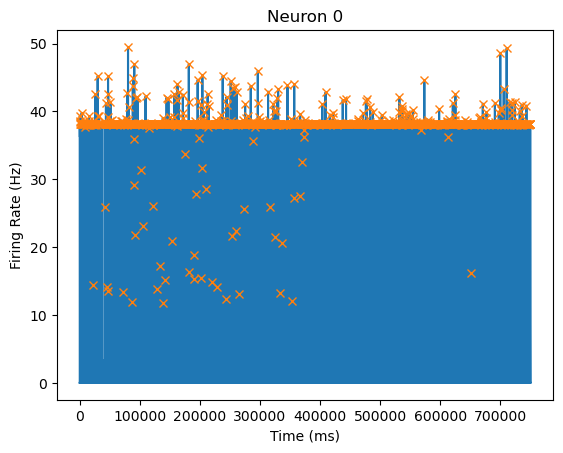

In [77]:
plt.plot(delay_fr[:,0])
plt.plot(burst_peaks, delay_fr[burst_peaks,0], "x")
plt.title('Neuron 0')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')
plt.show()

#### now do poisson

In [8]:
# first simulate the poisson data for each neuron

def generate_poisson_spiketimes(rate, total_dur):
    """
    Generate Poisson spike times based on the given firing rate.
    """
    # Calculate the number of spikes based on the firing rate and time duration
    num_spikes = np.random.poisson(rate * total_dur)
    
    # Generate random spike times
    spike_times = np.sort(np.random.uniform(0, total_dur, num_spikes))
    
    return spike_times

def convert_spike_to_rate(spike_times, total_dur, bin_size, sigma):
    """
    Convert spike times to firing rate using Gaussian smoothing.
    """
    # Create a histogram of spike counts
    spike_counts, _ = np.histogram(spike_times, bins=np.arange(0, total_dur + bin_size, bin_size))
    
    # Create a Gaussian kernel
    # kernel = gaussian(int(sigma / bin_size), std=sigma / bin_size)
    kernel = gaussian(len(spike_counts), std=sigma / bin_size)
    
    # Convolve the histogram with the Gaussian kernel
    smoothed_rate = np.convolve(spike_counts, kernel, mode='same') / np.sum(kernel)
    
    return smoothed_rate

In [65]:
total_dur = trial_dur * n_trials
spike_counts, _ = np.histogram(poisson_spikes, bins=np.arange(0, total_dur + bin_size, bin_size))
    
# Create a Gaussian kernel
# kernel = gaussian(int(sigma / bin_size), std=sigma / bin_size)
kernel = gaussian(len(spike_counts), std=sigma / bin_size)
# from scipy.signal.windows import exponential
# kernel = exponential(len(spike_counts), center=0, sym=False)

# Convolve the histogram with the Gaussian kernel
smoothed_rate = np.convolve(spike_counts, kernel, mode='same') / np.sum(kernel)

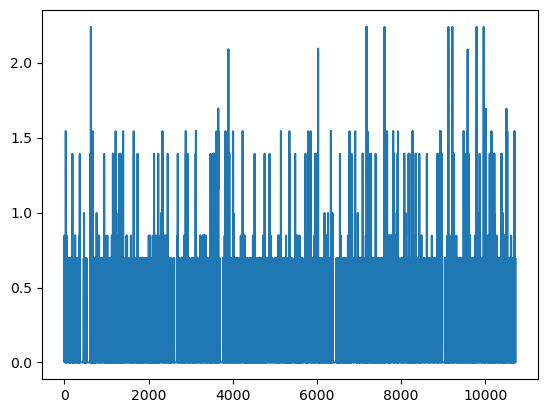

In [67]:
plt.plot(smoothed_rate);

In [55]:
poisson_fr = np.zeros_like(delay_fr)
for i in range(n_neurons):
    poisson_spikes = []
    for j in range(n_trials):
        poisson_spktimes = generate_poisson_spiketimes(neuron_avg_fr[i,j]/fs_dict['ds'], trial_dur)
        poisson_spikes.append(poisson_spktimes + j*trial_dur)

    poisson_spikes = np.concatenate(poisson_spikes)
    poisson_fr[:,i] = convert_spike_to_rate(poisson_spikes, trial_dur, bin_size, sigma)
    break


ValueError: could not broadcast input array from shape (25,) into shape (750000,)

In [ ]:
df_category = df_subject[df_subject['Neuron_ID_3'].isin(neuron_ids)]
num_trials = df_category['trial_id'].nunique()
if num_trials == 0:
    continue

spike_times_all = []
neuron_indices = []
neuron_spike_counts = {}
neuron_trial_counts = {}

for trial_idx, trial_id in enumerate(sorted(df_category['trial_id'].unique())):
    df_trial = df_category[df_category['trial_id'] == trial_id]
    for neuron_idx, neuron_id in enumerate(sorted(df_trial['Neuron_ID_3'].unique())):
        neuron_spikes = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
        spikes_found = False
        neuron_spike_list = []
        if not neuron_spikes.empty:
            all_spikes = []
            for spikes in neuron_spikes:
                if spikes != '[]':
                    spike_times = np.array(eval(spikes))
                    spike_times = spike_times[(spike_times >= 0) & (spike_times <= 2.8)]
                    if len(spike_times) > 0:
                        all_spikes.extend(spike_times)
                        spike_times += trial_idx * 2.8
                        neuron_spike_list.extend(spike_times)
                        spikes_found = True

            if neuron_id not in neuron_spike_counts:
                neuron_spike_counts[neuron_id] = 0
                neuron_trial_counts[neuron_id] = 0
            neuron_spike_counts[neuron_id] += len(neuron_spike_list)
            neuron_trial_counts[neuron_id] += 1

        spike_times_all.append(neuron_spike_list if spikes_found else [])
        neuron_indices.append(neuron_idx)

neuron_firing_rates = {
    neuron_id: (neuron_spike_counts[neuron_id] / (2.8 * neuron_trial_counts[neuron_id]))
    if neuron_trial_counts[neuron_id] > 0 else 0
    for neuron_id in neuron_spike_counts
}

if not any(spike_times_all):
    print(f"Skipping Subject {subject_id}, Category {category}: No spikes found.")
    continue

total_duration = num_trials * 2.8
time_bins = np.arange(0, total_duration + bin_size, bin_size)
spikes_to_concatenate = [spikes for spikes in spike_times_all if len(spikes) > 0]
spike_counts, _ = np.histogram(np.concatenate(spikes_to_concatenate), bins=time_bins)
gaussian_kernel = gaussian(len(spike_counts), std=sigma/bin_size)
smoothed_firing_rate = np.convolve(spike_counts, gaussian_kernel, mode='same') / np.sum(gaussian_kernel)
prominence_threshold = np.percentile(smoothed_firing_rate, prominence_threshold_percentile)
burst_peaks, _ = signal.find_peaks(smoothed_firing_rate, prominence=prominence_threshold)
results_delay[category]["real_bursts"].append(len(burst_peaks))

poisson_burst_counts = []
for _ in range(100):
    poisson_spike_times_all = []
    for trial_idx, trial_id in enumerate(sorted(df_category['trial_id'].unique())):
        df_trial = df_category[df_category['trial_id'] == trial_id]

        for neuron_id in df_trial['Neuron_ID_3'].unique():
            trial_spike_data = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
            trial_spikes = []

            for spikes in trial_spike_data:
                if spikes != '[]':
                    s = np.array(eval(spikes))
                    s = s[(s >= 0) & (s <= 2.8)]
                    trial_spikes.extend(s)

            trial_rate = len(trial_spikes) / 2.8 if len(trial_spikes) > 0 else 0
            expected_spikes = np.random.poisson(trial_rate * 2.8)
            poisson_spikes = np.sort(np.random.uniform(0, 2.8, expected_spikes))
            poisson_spikes += trial_idx * 2.8
            poisson_spike_times_all.append(poisson_spikes)

    poisson_spikes_to_concatenate = [spikes for spikes in poisson_spike_times_all if len(spikes) > 0]
    if not poisson_spikes_to_concatenate:
        poisson_burst_counts.append(0)
        continue

    poisson_spike_counts, _ = np.histogram(np.concatenate(poisson_spikes_to_concatenate), bins=time_bins)
    smoothed_poisson_firing_rate = np.convolve(poisson_spike_counts, gaussian_kernel, mode='same') / np.sum(gaussian_kernel)
    poisson_burst_peaks, _ = signal.find_peaks(smoothed_poisson_firing_rate, prominence=prominence_threshold)
    poisson_burst_counts.append(len(poisson_burst_peaks))

results_delay[category]["poisson_bursts"].append(np.mean(poisson_burst_counts))

Processing Subject 1...
Processing Subject 2...
Processing Subject 3...
Processing Subject 4...
Processing Subject 5...
Processing Subject 6...
Processing Subject 7...
Processing Subject 8...
Processing Subject 9...
Processing Subject 10...
Processing Subject 11...
Processing Subject 12...
Processing Subject 13...
Processing Subject 14...
Processing Subject 15...
Processing Subject 16...
Processing Subject 17...
Processing Subject 18...
Processing Subject 19...
Processing Subject 21...


We get summary statistics (across subjects) and we plot the real vs Poisson spikes for different neuron categories. 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


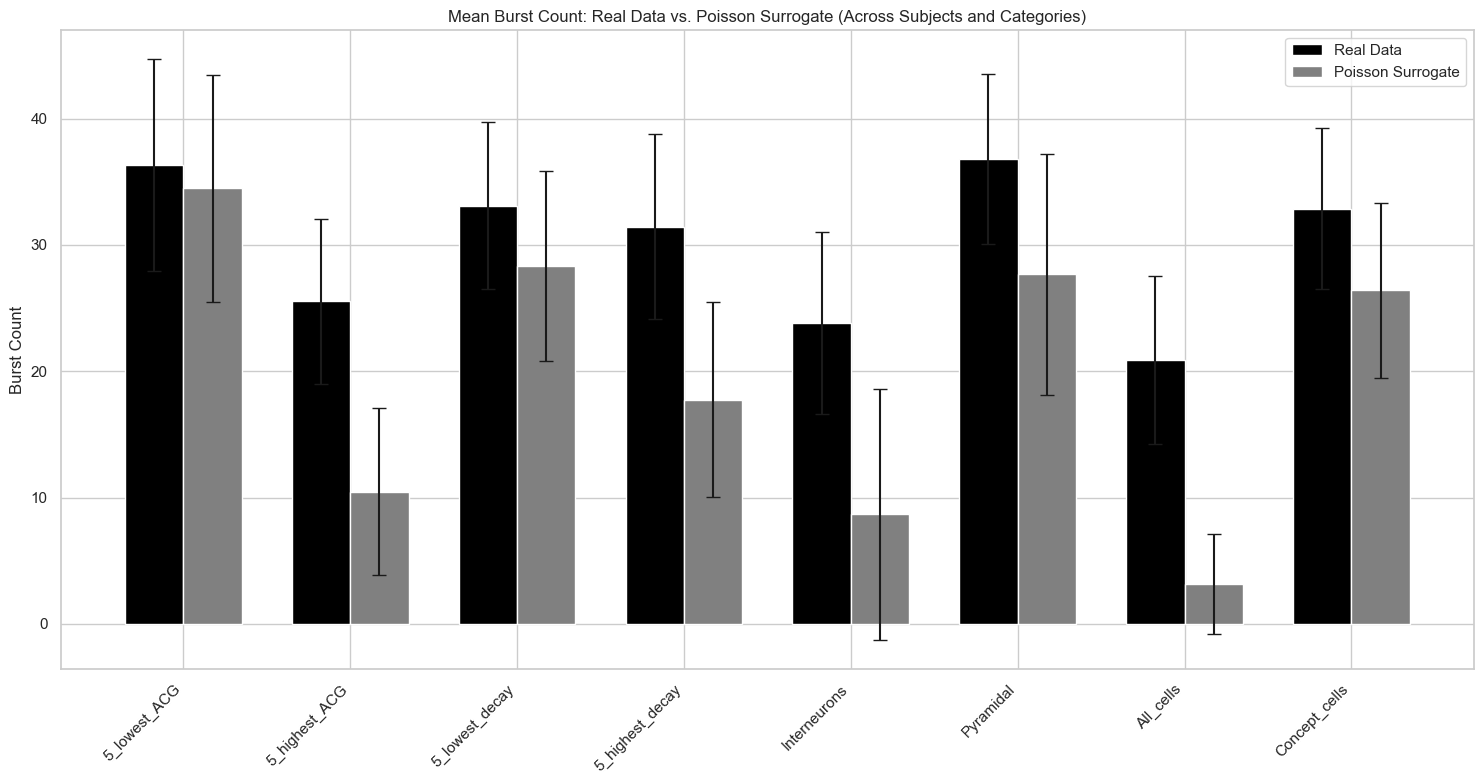

In [14]:
# Compute summary statistics
category_means = {
    category: {
        "real_mean": np.mean(results_delay[category]["real_bursts"]),
        "real_std": np.std(results_delay[category]["real_bursts"]),
        "poisson_mean": np.mean(results_delay[category]["poisson_bursts"]),
        "poisson_std": np.std(results_delay[category]["poisson_bursts"])
    } for category in categories
}

# Plot
plt.figure(figsize=(15, 8))
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, [category_means[c]["real_mean"] for c in categories],
        width, yerr=[category_means[c]["real_std"] for c in categories],
        capsize=5, label="Real Data", color='black')

plt.bar(x + width/2, [category_means[c]["poisson_mean"] for c in categories],
        width, yerr=[category_means[c]["poisson_std"] for c in categories],
        capsize=5, label="Poisson Surrogate", color='gray')

plt.xticks(x, categories, rotation=45, ha='right')
plt.ylabel("Burst Count")
plt.title("Mean Burst Count: Real Data vs. Poisson Surrogate (Across Subjects and Categories)")
plt.legend()
plt.tight_layout()
plt.savefig("/Users/darikussovska/Desktop/bursting_delay.eps", format='eps', dpi=300)
plt.show()

We perform stats between the Real vs Poisson bursts. We check for normality of burst counts, and we use the appropriate statistical tests. 

In [15]:
from scipy.stats import shapiro, ttest_rel, wilcoxon

stats_results = {category: {} for category in categories}

# Loop through each category
for category in categories:
    print(f"\nAnalyzing Category: {category}")

    # Extract real and Poisson burst counts for this category
    real_bursts = results_delay[category]["real_bursts"]
    poisson_bursts = results_delay[category]["poisson_bursts"]

    # Skip if no data for this category
    if not real_bursts or not poisson_bursts:
        print(f"Skipping {category}: No data available.")
        continue

    # Check normality of real and Poisson burst counts
    shapiro_real = shapiro(real_bursts)
    shapiro_poisson = shapiro(poisson_bursts)

    print(f"Shapiro-Wilk test for real burst counts: p-value = {shapiro_real.pvalue:.4f}")
    print(f"Shapiro-Wilk test for Poisson burst counts: p-value = {shapiro_poisson.pvalue:.4f}")

    # Perform statistical test based on normality
    if shapiro_real.pvalue > 0.05 and shapiro_poisson.pvalue > 0.05:
        # Both datasets are normally distributed: use paired t-test
        print("Both datasets are normally distributed. Using paired t-test.")
        test_result = ttest_rel(real_bursts, poisson_bursts)
        test_name = "Paired t-test"
    else:
        # One or both datasets are not normally distributed: use Wilcoxon signed-rank test
        print("One or both datasets are not normally distributed. Using Wilcoxon signed-rank test.")
        test_result = wilcoxon(real_bursts, poisson_bursts)
        test_name = "Wilcoxon signed-rank test"

    # Store test results
    stats_results[category] = {
        "test_name": test_name,
        "statistic": test_result.statistic,
        "pvalue": test_result.pvalue
    }

    print(f"{test_name} results: statistic = {test_result.statistic:.4f}, p-value = {test_result.pvalue:.4f}")

    # Check significance
    alpha = 0.001 / len(categories)  # Bonferroni correction
    if test_result.pvalue < alpha:
        print(f"The difference in burst counts is statistically significant (p < {alpha:.4f}).")
    else:
        print(f"The difference in burst counts is not statistically significant (p >= {alpha:.4f}).")


Analyzing Category: 5_lowest_ACG
Shapiro-Wilk test for real burst counts: p-value = 0.4269
Shapiro-Wilk test for Poisson burst counts: p-value = 0.0693
Both datasets are normally distributed. Using paired t-test.
Paired t-test results: statistic = 1.5399, p-value = 0.1401
The difference in burst counts is not statistically significant (p >= 0.0001).

Analyzing Category: 5_highest_ACG
Shapiro-Wilk test for real burst counts: p-value = 0.3981
Shapiro-Wilk test for Poisson burst counts: p-value = 0.0001
One or both datasets are not normally distributed. Using Wilcoxon signed-rank test.
Wilcoxon signed-rank test results: statistic = 1.0000, p-value = 0.0000
The difference in burst counts is statistically significant (p < 0.0001).

Analyzing Category: 5_lowest_decay
Shapiro-Wilk test for real burst counts: p-value = 0.5123
Shapiro-Wilk test for Poisson burst counts: p-value = 0.8234
Both datasets are normally distributed. Using paired t-test.
Paired t-test results: statistic = 2.9170, p-va

We can also visualise the real vs poisson bursts for a particular subject and category across the concatenated trials. 

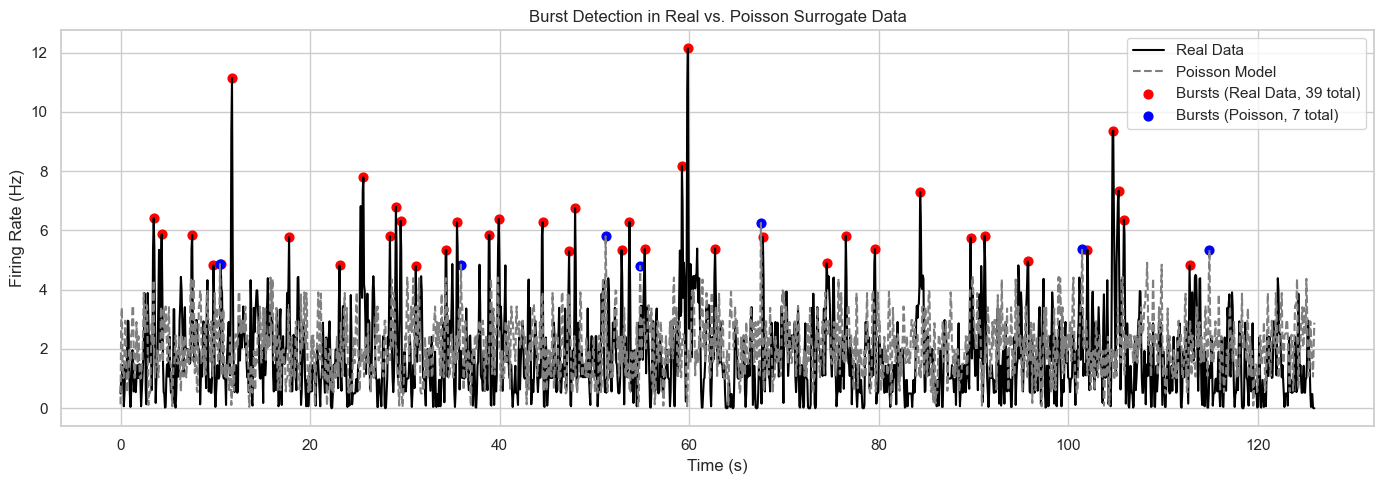

In [ ]:
import matplotlib.pyplot as plt
subject_id = 14
category_name = "All_cells"
df_subject_metadata = df_metadata[df_metadata['subject_id'] == subject_id]
df_subject = df_enc1_filtered[
    (df_enc1_filtered['subject_id'] == subject_id) &
    (df_enc1_filtered['num_images_presented'] == 1)
]
neuron_ids = df_subject_metadata['Neuron_ID_3'].tolist()
df_category = df_subject[df_subject['Neuron_ID_3'].isin(neuron_ids)]
trial_ids = sorted(df_category['trial_id'].unique())
num_trials = len(trial_ids)
spike_times_all = []
for trial_idx, trial_id in enumerate(trial_ids):
    df_trial = df_category[df_category['trial_id'] == trial_id]
    for neuron_id in sorted(df_trial['Neuron_ID_3'].unique()):
        neuron_spikes = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
        trial_spikes = []
        for spikes in neuron_spikes:
            if spikes != '[]':
                spike_times = np.array(eval(spikes))
                spike_times = spike_times[(spike_times >= 0) & (spike_times <= 2.8)]
                spike_times += trial_idx * 2.8
                trial_spikes.extend(spike_times)
        spike_times_all.append(trial_spikes)
real_all_spikes = np.concatenate([s for s in spike_times_all if len(s) > 0])
total_duration = num_trials * 2.8
time_bins = np.arange(0, total_duration + bin_size, bin_size)
spike_counts, _ = np.histogram(real_all_spikes, bins=time_bins)
gaussian_kernel = gaussian(len(spike_counts), std=sigma / bin_size)
smoothed_firing_rate = np.convolve(spike_counts, gaussian_kernel, mode='same') / np.sum(gaussian_kernel)
real_bursts, _ = signal.find_peaks(smoothed_firing_rate, prominence=np.percentile(smoothed_firing_rate, prominence_threshold_percentile))
neuron_firing_rates = {}
for neuron_id in df_category['Neuron_ID_3'].unique():
    df_neuron = df_category[df_category['Neuron_ID_3'] == neuron_id]
    total_spikes = 0
    valid_trials = 0
    for spikes in df_neuron['Standardized_Spikes_in_Delay'].dropna():
        if spikes != '[]':
            s = np.array(eval(spikes))
            s = s[(s >= 0) & (s <= 2.8)]
            total_spikes += len(s)
            valid_trials += 1
    if valid_trials > 0:
        neuron_firing_rates[neuron_id] = total_spikes / (valid_trials * 2.8)
poisson_spike_times_all = []
for trial_idx, trial_id in enumerate(trial_ids):
    df_trial = df_category[df_category['trial_id'] == trial_id]
    for neuron_id in df_trial['Neuron_ID_3'].unique():
        trial_spike_data = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
        trial_spikes = []
        for spikes in trial_spike_data:
            if spikes != '[]':
                spikes = np.array(eval(spikes))
                spikes = spikes[(spikes >= 0) & (spikes <= 2.8)]
                trial_spikes.extend(spikes)
        trial_rate = len(trial_spikes) / 2.8 if len(trial_spikes) > 0 else 0
        expected_spikes = np.random.poisson(trial_rate * 2.8)
        poisson_spikes = np.sort(np.random.uniform(0, 2.8, expected_spikes))
        poisson_spikes += trial_idx * 2.8
        poisson_spike_times_all.append(poisson_spikes)
        poisson_all_spikes = np.concatenate([s for s in poisson_spike_times_all if len(s) > 0])
        poisson_spike_counts, _ = np.histogram(poisson_all_spikes, bins=time_bins)
        smoothed_poisson = np.convolve(poisson_spike_counts, gaussian_kernel, mode='same') / np.sum(gaussian_kernel)
        poisson_bursts, _ = signal.find_peaks(smoothed_poisson, prominence=np.percentile(smoothed_poisson, prominence_threshold_percentile))
plt.figure(figsize=(14, 5))
plt.plot(time_bins[:-1], smoothed_firing_rate, color='black', label='Real Data')
plt.plot(time_bins[:-1], smoothed_poisson, color='gray', linestyle='--', label='Poisson Model')
plt.scatter(time_bins[real_bursts], smoothed_firing_rate[real_bursts], color='red', s=40, label=f'Bursts (Real Data, {len(real_bursts)} total)')
plt.scatter(time_bins[poisson_bursts], smoothed_poisson[poisson_bursts], color='blue', s=40, label=f'Bursts (Poisson, {len(poisson_bursts)} total)')
plt.title("Burst Detection in Real vs. Poisson Surrogate Data")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.savefig("/Users/darikussovska/Desktop/PROJECT/Figures/Bursting/example_bursting.eps", format='eps', dpi=300)
plt.show()

Now that we know that the real bursts occur significantly more than chance (in all cells and certain groups of neurons), we can continue with other analysis. So we reuse the same functions for counting bursts, but this time we add the load into the entire loop to see how bursts change across different loads. 

In [8]:
import warnings
warnings.filterwarnings('ignore')

df_metadata = pd.read_excel('/Users/darikussovska/Desktop/Cells.xlsx')
df_delay = pd.read_excel('/Users/darikussovska/Desktop/PROJECT/graph_delay.xlsx')

# Any New Parameters 
loads = [1, 2, 3]
delay_duration = 2.8

burst_counts_by_load = {cat: {load: [] for load in loads} for cat in categories}
subject_ids = [s for s in df_metadata['subject_id'].unique() if s != 20]

# === Loop Over Subjects and Loads ===
for subject_id in subject_ids:
    df_subject_metadata = df_metadata[df_metadata['subject_id'] == subject_id]

    for load in loads:
        df_subject = df_delay[
            (df_delay['subject_id'] == subject_id) &
            (df_delay['num_images_presented'] == load)
        ]

        if df_subject.empty:
            continue

        neuron_subsets = {
            "5_lowest_ACG": df_subject_metadata.nsmallest(5, 'Mean_ACG')['Neuron_ID_3'].tolist(),
            "5_highest_ACG": df_subject_metadata.nlargest(5, 'Mean_ACG')['Neuron_ID_3'].tolist(),
            "5_lowest_decay": df_subject_metadata.nsmallest(5, 'Decay')['Neuron_ID_3'].tolist(),
            "5_highest_decay": df_subject_metadata.nlargest(5, 'Decay')['Neuron_ID_3'].tolist(),
            "Interneurons": df_subject_metadata[df_subject_metadata['Cell_Type'] == 'IN']['Neuron_ID_3'].tolist(),
            "Pyramidal": df_subject_metadata[df_subject_metadata['Cell_Type'] == 'PY']['Neuron_ID_3'].tolist(),
            "All_cells": df_subject_metadata['Neuron_ID_3'].tolist(),
            "Concept_cells": df_subject_metadata[df_subject_metadata['Signi'] == 'Y']['Neuron_ID_3'].tolist()
        }

        for category, neuron_ids in neuron_subsets.items():
            if not neuron_ids:
                continue

            df_category = df_subject[df_subject['Neuron_ID_3'].isin(neuron_ids)]
            spike_times_all = []

            trial_ids = sorted(df_category['trial_id'].unique())
            num_trials = len(trial_ids)
            if num_trials < 1:
                continue

            for trial_idx, trial_id in enumerate(trial_ids):
                df_trial = df_category[df_category['trial_id'] == trial_id]

                for neuron_id in sorted(df_trial['Neuron_ID_3'].unique()):
                    neuron_spikes = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
                    trial_spikes = []

                    if not neuron_spikes.empty:
                        for spikes in neuron_spikes:
                            if spikes != '[]':
                                spike_times = np.array(eval(spikes))
                                spike_times = spike_times[(spike_times >= 0) & (spike_times <= delay_duration)]
                                spike_times += trial_idx * delay_duration
                                trial_spikes.extend(spike_times)

                    spike_times_all.append(trial_spikes)

            if not any(len(spikes) > 0 for spikes in spike_times_all):
                continue

            total_duration = num_trials * delay_duration
            time_bins = np.arange(0, total_duration + bin_size, bin_size)
            all_spikes = np.concatenate([spikes for spikes in spike_times_all if len(spikes) > 0])
            spike_counts, _ = np.histogram(all_spikes, bins=time_bins)

            gaussian_kernel = gaussian(len(spike_counts), std=sigma / bin_size)
            smoothed_firing_rate = np.convolve(spike_counts, gaussian_kernel, mode='same') / np.sum(gaussian_kernel)

            prominence_threshold = np.percentile(smoothed_firing_rate, prominence_threshold_percentile)
            burst_peaks, _ = signal.find_peaks(smoothed_firing_rate, prominence=prominence_threshold)
            real_burst_count = len(burst_peaks)

            burst_counts_by_load[category][load].append(real_burst_count)

Now we visualise and compute stats

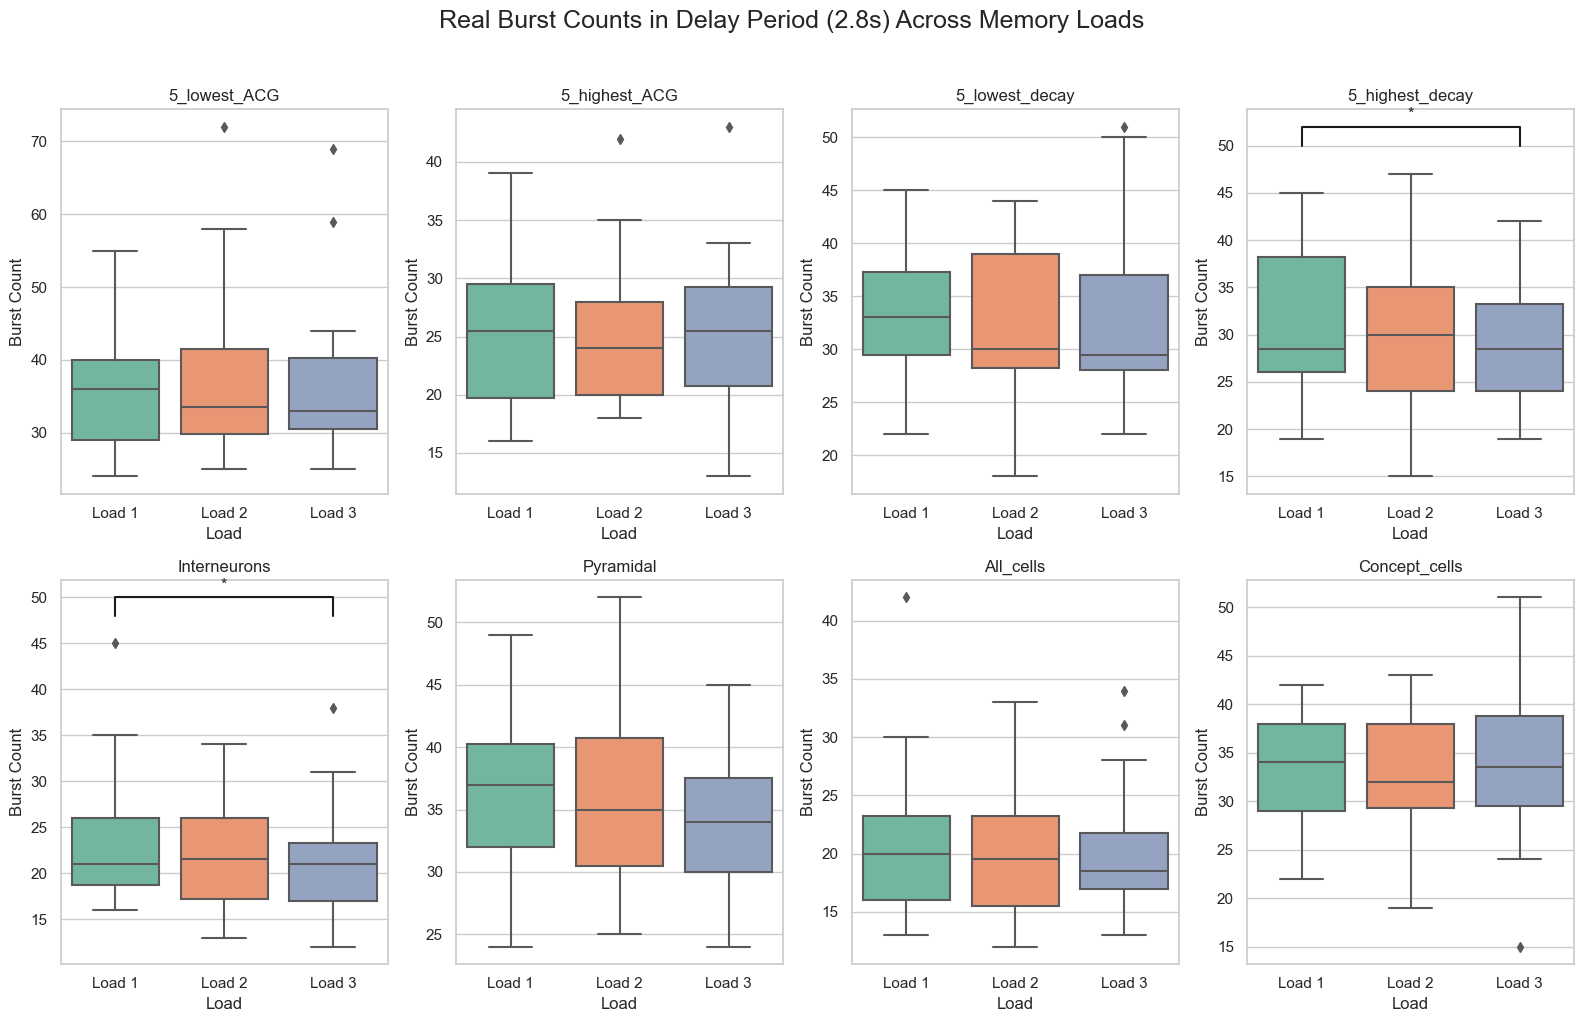

In [10]:
import seaborn as sns

# === Convert to DataFrame for Visualization ===
plot_data = []
for category in categories:
    for load in loads:
        for value in burst_counts_by_load[category][load]:
            plot_data.append({
                "Category": category,
                "Load": f"Load {load}",
                "Burst Count": value
            })
df_plot = pd.DataFrame(plot_data)

# === Plotting ===
plt.figure(figsize=(16, 10))
sns.set(style="whitegrid")

for i, category in enumerate(categories, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x='Load', y='Burst Count', data=df_plot[df_plot['Category'] == category], palette='Set2')
    plt.title(category)

    g1 = burst_counts_by_load[category][1]
    g2 = burst_counts_by_load[category][2]
    g3 = burst_counts_by_load[category][3]

    try:
        p12 = wilcoxon(g1, g2).pvalue if len(g1) == len(g2) else np.nan
        p13 = wilcoxon(g1, g3).pvalue if len(g1) == len(g3) else np.nan
        p23 = wilcoxon(g2, g3).pvalue if len(g2) == len(g3) else np.nan
    except:
        p12 = p13 = p23 = np.nan

    y_max = max(g1 + g2 + g3) if (g1 and g2 and g3) else 0

    def add_star(p, x1, x2, h, offset=2):
        if not np.isnan(p) and p < 0.05:
            plt.plot([x1, x1, x2, x2], [h, h+offset, h+offset, h], lw=1.5, c='k')
            plt.text((x1 + x2)/2, h+offset+0.5, '*', ha='center', va='bottom', fontsize=12)

    add_star(p12, 0, 1, y_max + 1)
    add_star(p13, 0, 2, y_max + 3)
    add_star(p23, 1, 2, y_max + 5)

    plt.tight_layout()

plt.suptitle("Real Burst Counts in Delay Period (2.8s) Across Memory Loads", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Ranking the neurons inside of a burst (which one spiked first, second, third, etc.). For a single subjects. Can try within subjects as well.

In [27]:
from collections import defaultdict

subject_id = 3
category = "All_cells"
burst_window = 0.1 # 100ms window around each burst peak

# Store all spike times by neuron across trials
df_subject_metadata = df_metadata[df_metadata['subject_id'] == subject_id]
df_subject = df_enc1_filtered[
    (df_enc1_filtered['subject_id'] == subject_id) &
    (df_enc1_filtered['num_images_presented'] == 1)
]
neuron_ids = df_subject_metadata['Neuron_ID_3'].tolist()
df_category = df_subject[df_subject['Neuron_ID_3'].isin(neuron_ids)]
trial_ids = sorted(df_category['trial_id'].unique())

# Build spike dictionary: neuron_id → spike_times (concatenated across trials)
neuron_spikes_dict = defaultdict(list)

for trial_idx, trial_id in enumerate(trial_ids):
    df_trial = df_category[df_category['trial_id'] == trial_id]
    for neuron_id in df_trial['Neuron_ID_3'].unique():
        spike_data = df_trial[df_trial['Neuron_ID_3'] == neuron_id]['Standardized_Spikes_in_Delay'].dropna()
        for spikes in spike_data:
            if spikes != '[]':
                spike_times = np.array(eval(spikes))
                spike_times = spike_times[(spike_times >= 0) & (spike_times <= 2.8)]
                spike_times += trial_idx * 2.8
                neuron_spikes_dict[neuron_id].extend(spike_times)

# Convert burst peak indices to times
burst_times = time_bins[burst_peaks]

burst_ranking = [] 

for bt in burst_times:
    window_start = bt - burst_window / 2
    window_end = bt + burst_window / 2
    first_spikes = []

    for neuron_id, spikes in neuron_spikes_dict.items():
        spikes_in_window = [s for s in spikes if window_start <= s <= window_end]
        if spikes_in_window:
            first_spike = min(spikes_in_window)
            first_spikes.append((neuron_id, first_spike))

    # Sort neurons by first spike time
    ranked = sorted(first_spikes, key=lambda x: x[1])
    burst_ranking.append([n for n, _ in ranked])  

print("Example ranked neuron list for first 3 bursts:")
for i, ranked_neurons in enumerate(burst_ranking[:3]):
    print(f"Burst {i+1}: {ranked_neurons}")

Example ranked neuron list for first 3 bursts:
Burst 1: [304, 300, 3027, 3014, 3020, 3022, 3010, 3013, 3011, 3019, 3015]
Burst 2: [3017, 3022, 307, 3026, 3015, 3024, 309]
Burst 3: [3027, 3017, 3015, 3022]


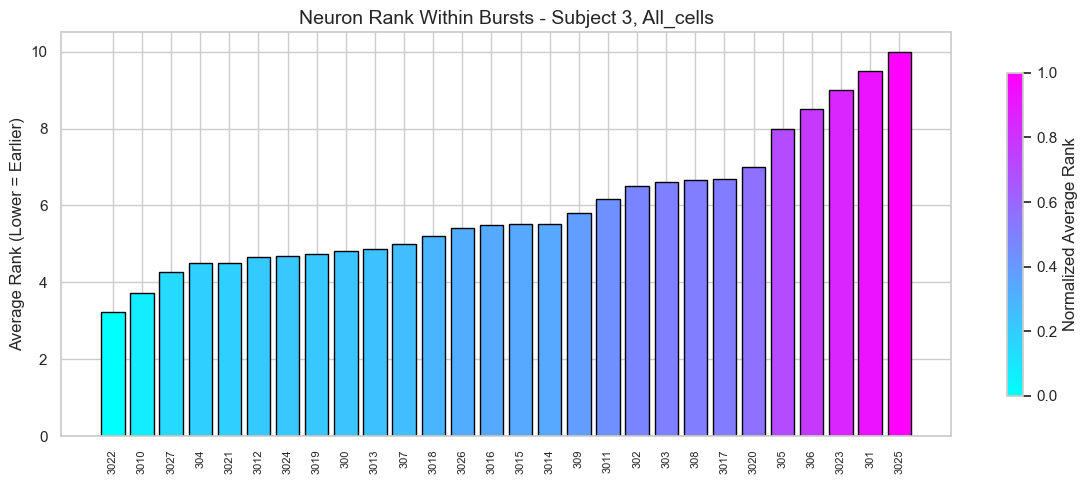

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

cmap = plt.get_cmap("cool")  

# Normalize rank values for color mapping
norm_ranks = np.array([avg_ranks[n] for n in ranked_neurons])
norm = (norm_ranks - norm_ranks.min()) / (norm_ranks.max() - norm_ranks.min() + 1e-6)  # avoid div/0
colors = [cmap(val) for val in norm]

plt.figure(figsize=(12, 5))
bars = plt.bar(
    range(len(avg_ranks)),
    norm_ranks,
    color=colors,
    edgecolor='black'
)

plt.xticks(range(len(avg_ranks)), ranked_neurons, rotation=90, fontsize=8)
plt.ylabel("Average Rank (Lower = Earlier)", fontsize=12)
plt.title(f"Neuron Rank Within Bursts - Subject {subject_id}, {category}", fontsize=14)
plt.tight_layout()
plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap),
    label="Normalized Average Rank",
    orientation='vertical',
    shrink=0.8
)
plt.show()